In [77]:
import numpy as np
from mpi4py import MPI
from petsc4py import PETSc

import dolfinx
import dolfinx.mesh
import dolfinx.fem
import dolfinx.fem.petsc
import dolfinx.geometry
import dolfinx.io

import ufl
from ufl import dx, grad, dot, inner, TestFunction, TrialFunction
from ufl import CellDiameter, sqrt, conditional, gt

print(f"DOLFINx version : {dolfinx.__version__}")

DOLFINx version : 0.9.0


In [ ]:
D     = 1e-2                   # diffusivité scalaire
b_val = np.array([1.0, 0.3])  # vecteur de convection
f_mag = 10.0                   # intensité de la source
x0    = np.array([0.5, 0.5])  # position de la source ponctuelle
N     = 500                     # résolution maillage N×N

# Péclet global (indicateur de stabilité)
L  = 1.0  # taille du domaine
Pe = np.linalg.norm(b_val) * L / D
print(f"Péclet global Pe = {Pe:.1f}")

Péclet global Pe = 104.4


In [79]:
msh = dolfinx.mesh.create_unit_square(
    MPI.COMM_WORLD, N, N,
    cell_type=dolfinx.mesh.CellType.triangle
)

print(f"Nombre de cellules : {msh.topology.index_map(2).size_global}")
print(f"Nombre de noeuds   : {msh.topology.index_map(0).size_global}")

Nombre de cellules : 8192
Nombre de noeuds   : 4225


In [80]:
V = dolfinx.fem.functionspace(msh, ("Lagrange", 1))

u = TrialFunction(V)   # inconnue
v = TestFunction(V)    # fonction test

print(f"Degrés de liberté : {V.dofmap.index_map.size_global}")

Degrés de liberté : 4225


In [81]:
b      = dolfinx.fem.Constant(msh, PETSc.ScalarType(b_val))
D_coef = dolfinx.fem.Constant(msh, PETSc.ScalarType(D))

# Convection + diffusion (issu de la formulation variationnelle + Green)
a_std = (dot(b, grad(u)) * v + D_coef * inner(grad(u), grad(v))) * dx

# Paramètre de stabilisation SUPG
h      = CellDiameter(msh)
b_norm = sqrt(dot(b, b) + 1e-14)
Pe_h   = b_norm * h / (2.0 * D_coef)
tau    = (h / (2.0 * b_norm)) * conditional(gt(Pe_h, 1.0), 1.0, Pe_h / 3.0)

# Terme SUPG : ajoute diffusion artificielle dans le sens du flux
a_supg = tau * dot(b, grad(v)) * dot(b, grad(u)) * dx

a = a_std
print("Forme bilinéaire a(u,v) définie avec SUPG")

Forme bilinéaire a(u,v) définie avec SUPG


In [82]:
# L(v) = 0 pour l'instant — la source ponctuelle sera injectée dans le RHS
zero = dolfinx.fem.Constant(msh, PETSc.ScalarType(0.0))
L    = zero * v * dx

# Dirichlet u=0 sur tout le bord
msh.topology.create_connectivity(msh.topology.dim - 1, msh.topology.dim)
boundary_facets = dolfinx.mesh.exterior_facet_indices(msh.topology)
boundary_dofs   = dolfinx.fem.locate_dofs_topological(
    V, msh.topology.dim - 1, boundary_facets
)
bc = dolfinx.fem.dirichletbc(PETSc.ScalarType(0.0), boundary_dofs, V)

print(f"Noeuds sur le bord : {len(boundary_dofs)}")

Noeuds sur le bord : 256


In [83]:
a_form = dolfinx.fem.form(a)
L_form = dolfinx.fem.form(L)

# Matrice de rigidité
A = dolfinx.fem.petsc.assemble_matrix(a_form, bcs=[bc])
A.assemble()

# Vecteur RHS
b_rhs = dolfinx.fem.petsc.assemble_vector(L_form)

# Appliquer les corrections Dirichlet sur le RHS
dolfinx.fem.petsc.apply_lifting(b_rhs, [a_form], bcs=[[bc]])
b_rhs.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)

print(f"Matrice A : {A.getSize()}")
print("RHS assemblé")

Matrice A : (4225, 4225)
RHS assemblé


In [84]:
def add_point_source(b_vec, V, x0_2d, magnitude):
    """
    Injecte f·δ(x−x0) dans le vecteur RHS.

    Principe : L(v) = f·v(x0)
    Pour P1, v(x0) = Σ_i φ_i(x0) * v_i
    où φ_i(x0) = coordonnée barycentrique i de x0 dans son triangle.
    On injecte donc f·φ_i(x0) dans la composante i du RHS.
    """
    x0_3d = np.array([[x0_2d[0], x0_2d[1], 0.0]])

    # Trouver le triangle contenant x0
    bb_tree    = dolfinx.geometry.bb_tree(V.mesh, V.mesh.topology.dim)
    candidates = dolfinx.geometry.compute_collisions_points(bb_tree, x0_3d)
    cells      = dolfinx.geometry.compute_colliding_cells(V.mesh, candidates, x0_3d)

    if len(cells.links(0)) == 0:
        raise ValueError(f"x0={x0_2d} est hors du domaine !")

    cell_id = cells.links(0)[0]

    # Coordonnées des 3 sommets du triangle
    verts_idx = V.mesh.geometry.dofmap[cell_id]
    verts     = V.mesh.geometry.x[verts_idx][:, :2]

    # Coordonnées barycentriques : φ_i(x0)
    T    = verts[:2, :] - verts[2, :]
    rhs  = x0_2d - verts[2, :]
    lam  = np.linalg.solve(T.T, rhs)
    bary = np.array([lam[0], lam[1], 1.0 - lam[0] - lam[1]])

    # Injecter dans le RHS
    dofs = V.dofmap.cell_dofs(cell_id)
    for i, dof in enumerate(dofs):
        b_vec.setValue(int(dof), magnitude * bary[i], True)

    b_vec.assemble()
    print(f"Source ponctuelle injectée en x0={x0_2d}, cellule #{cell_id}")
    print(f"Coordonnées barycentriques : {bary.round(4)}")


add_point_source(b_rhs, V, x0, f_mag)

# Imposer les valeurs Dirichlet dans le RHS
dolfinx.fem.petsc.set_bc(b_rhs, [bc])

Source ponctuelle injectée en x0=[0.5 0.5], cellule #4127
Coordonnées barycentriques : [0. 0. 1.]


In [85]:
u_sol = dolfinx.fem.Function(V)

ksp = PETSc.KSP().create(msh.comm)
ksp.setOperators(A)
ksp.setType("gmres")        # GMRES : adapté aux matrices non-symétriques
ksp.getPC().setType("ilu")  # préconditionneur ILU
ksp.setTolerances(rtol=1e-10)
ksp.setFromOptions()

ksp.solve(b_rhs, u_sol.x.petsc_vec)
u_sol.x.scatter_forward()

print(f"Convergé en {ksp.getIterationNumber()} itérations")
print(f"Résidu final  : {ksp.getResidualNorm():.2e}")
print(f"u max = {u_sol.x.array.max():.4f}")
print(f"u min = {u_sol.x.array.min():.4f}")

Convergé en 19 itérations
Résidu final  : 1.48e-08
u max = 331.6666
u min = -8.6832


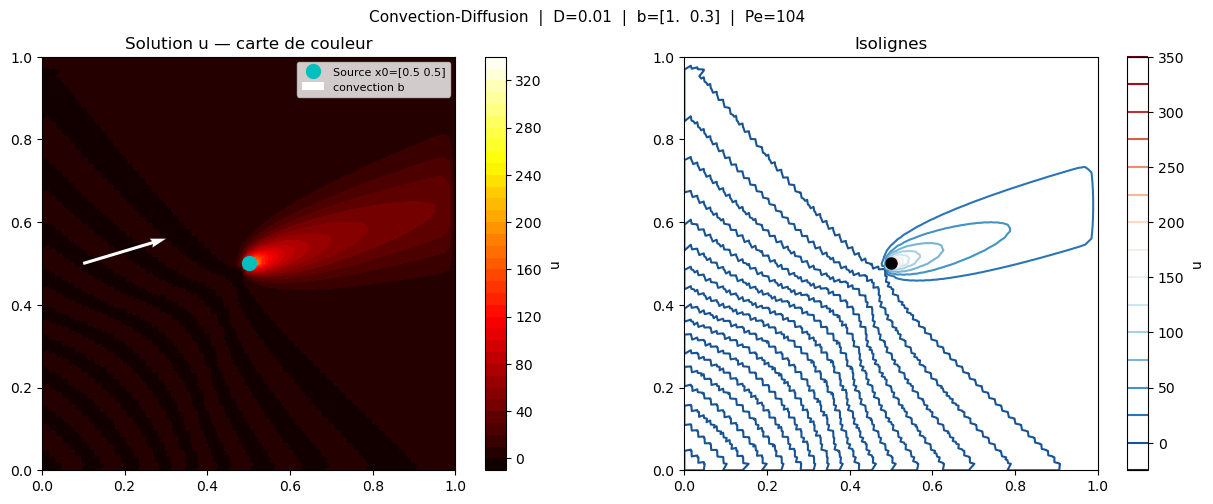

Figure sauvegardée → convdiff_solution.png


In [86]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

# Extraire les coordonnées et la triangulation
coords = msh.geometry.x[:, :2]          # (n_nodes, 2)
cells  = msh.geometry.dofmap            # connectivité des triangles
triang = mtri.Triangulation(coords[:, 0], coords[:, 1], cells)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Carte de couleur
ax = axes[0]
cf = ax.tricontourf(triang, u_sol.x.array.real, levels=40, cmap="hot")
plt.colorbar(cf, ax=ax, label="u")
ax.plot(*x0, 'co', markersize=10, label=f"Source x0={x0}")
ax.quiver(0.1, 0.5, b_val[0], b_val[1],
          scale=5, color='white', label='convection b')
ax.set_title("Solution u — carte de couleur")
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8)

# Courbes de niveau
ax = axes[1]
ct = ax.tricontour(triang, u_sol.x.array.real, levels=15, cmap="RdBu_r")
plt.colorbar(ct, ax=ax, label="u")
ax.plot(*x0, 'ko', markersize=8)
ax.set_title("Isolignes")
ax.set_aspect('equal')

plt.suptitle(f"Convection-Diffusion  |  D={D}  |  b={b_val}  |  Pe={Pe:.0f}",
             fontsize=11)
plt.tight_layout()
plt.savefig("convdiff_solution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée → convdiff_solution.png")